# Detecting AI-generated images: generalisation to unseen generators

**MSc dissertation — supervisor meeting**

Structure: **where the detector fails → what I changed → why → what that shows → supporting evidence.**

---

**Caveats that apply to everything below**

- **One seed per condition.** No error bars, no significance claims. A difference below ~0.05 ROC-AUC is not interpretable.
- **Zero-shot robustness** (before a generator is seen) and **adaptation** (after) are different questions and are never mixed.
- Dataset is **Tiny GenImage**, a reduced 7-generator derivative, not the full benchmark.


In [1]:
# Setup. This notebook is a PRESENTATION LAYER and contains no analysis logic: it calls
# scripts.build_meeting_pack, the same code that writes outputs/report/chapter4/, so what
# is shown here cannot drift from the saved artefacts.
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from scripts.build_meeting_pack import build, write_readme
from src.evaluation.aggregation import discover_runs, load_metrics, reportable_runs

OUTPUT_ROOT = REPO_ROOT / "outputs"
PACK = OUTPUT_ROOT / "report" / "chapter4"
ANALYSIS = OUTPUT_ROOT / "analysis"

SLIDES = build(PACK, OUTPUT_ROOT)
write_readme(SLIDES, PACK, OUTPUT_ROOT)
BY_NAME = {slide.filename: slide for slide in SLIDES}

records = discover_runs(OUTPUT_ROOT)
usable = reportable_runs(records)


def show(name, width=950):
    """Display one meeting figure with the line to say, what it shows, and its caveat."""
    slide = BY_NAME.get(name)
    if slide is None:
        display(Markdown(f"> **{name} could not be built from the current artefacts.**"))
        return
    flag = "  ·  ⚠️ **CONTAINS A PENDING ARM**" if slide.status == "pending" else ""
    display(Markdown(f"### {slide.heading}{flag}"))
    display(Image(filename=str(PACK / f"{name}.png"), width=width))
    display(Markdown(
        f"**Say:** {slide.say}\n\n"
        f"**Shows:** {slide.demonstrates}\n\n"
        f"**Caveat:** {slide.caveat}"
    ))


def cosine_result():
    """The modified detector's result, or None if that run has not finished."""
    for record in usable:
        if record.experiment_type == "unseen_generator" and record.experiment_name.endswith(
            "_cosine"
        ):
            gap = (load_metrics(record).get("generalisation_gap") or {}).get("roc_auc") or {}
            return {"run_id": record.run_id, **gap}
    return None


def _unseen(head_suffix):
    for record in usable:
        if record.experiment_type != "unseen_generator":
            continue
        is_cosine = record.experiment_name.endswith("_cosine")
        if record.held_out_generator == "vqdm" and is_cosine == (head_suffix == "cosine"):
            return record, load_metrics(record)
    return None, None


def head_comparison():
    """Both heads side by side on the identical held-out vqdm test set."""
    _, linear = _unseen("linear")
    _, cosine = _unseen("cosine")
    if linear is None or cosine is None:
        return []
    out = []
    for key, label in (("roc_auc", "ROC-AUC"), ("average_precision", "PR-AUC"),
                       ("f1_at_default_threshold", "F1@0.5")):
        gl, gc = linear["generalisation_gap"][key], cosine["generalisation_gap"][key]
        for field, name in (("in_distribution", "in-distribution"), ("unseen", "unseen vqdm"),
                            ("absolute_drop", "DEGRADATION")):
            out.append({
                "metric": f"{label} — {name}",
                "linear (769 params)": gl[field],
                "cosine (770 params)": gc[field],
                "difference": gc[field] - gl[field],
            })
    ul = linear["unseen_test"]["at_default_threshold"]
    uc = cosine["unseen_test"]["at_default_threshold"]
    for field in ("recall", "precision"):
        out.append({
            "metric": f"unseen {field}@0.5",
            "linear (769 params)": ul[field],
            "cosine (770 params)": uc[field],
            "difference": uc[field] - ul[field],
        })
    return out


def classify(result):
    """Apply the decision rule that was written into the config BEFORE the run."""
    _, linear = _unseen("linear")
    drop = result.get("absolute_drop")
    unseen_auc = result.get("unseen")
    gain = unseen_auc - linear["generalisation_gap"]["roc_auc"]["unseen"]
    in_dist_shift = (result.get("in_distribution")
                     - linear["generalisation_gap"]["roc_auc"]["in_distribution"])
    if drop <= 0.15 and unseen_auc >= 0.82 and abs(in_dist_shift) <= 0.01:
        return "CONVINCING", (
            f"Degradation fell to {drop:.4f} and unseen ROC-AUC reached {unseen_auc:.4f}, "
            "with in-distribution performance preserved.")
    if drop >= 0.29 or in_dist_shift < -0.01:
        return "FAILURE", (
            f"Degradation is {drop:.4f} and in-distribution moved {in_dist_shift:+.4f}. "
            "The modification did not help; this is a legitimate negative result.")
    return "INCONCLUSIVE", (
        f"Every direction favours the cosine head — degradation {0.2918:.4f} → {drop:.4f}, "
        f"unseen ROC-AUC {unseen_auc - gain:.4f} → {unseen_auc:.4f} ({gain:+.4f}), "
        f"in-distribution essentially unchanged ({in_dist_shift:+.4f}) — but the gain of "
        f"**{gain:+.4f} ROC-AUC is below the 0.05 threshold** fixed in advance as the "
        "smallest difference interpretable from a single seed. **Do not claim an "
        "improvement from this run alone.**")


print(f"{len(usable)} completed experiments included · {len(records) - len(usable)} excluded "
      f"(smoke / failed / interrupted)")


7 completed experiments included · 5 excluded (smoke / failed / interrupted)


---
# 1. BEFORE — the original detector

**Architecture.** CLIP ViT-B/32 vision encoder, **frozen**. It maps an image to a 768-dimensional embedding. On top sits a single linear layer, `Linear(768, 1)` — 768 weights and one bias, **769 trainable parameters**. The logit is `w·x + b`; a sigmoid turns it into P(fake).

**Training.** Leave-one-generator-out: train on six generators, hold the seventh out of training *and* model selection, then score it once on a balanced 500-image test set.

**The failure.** Degradation is severe but wildly generator-dependent.

### 1. Where does the original detector fail?

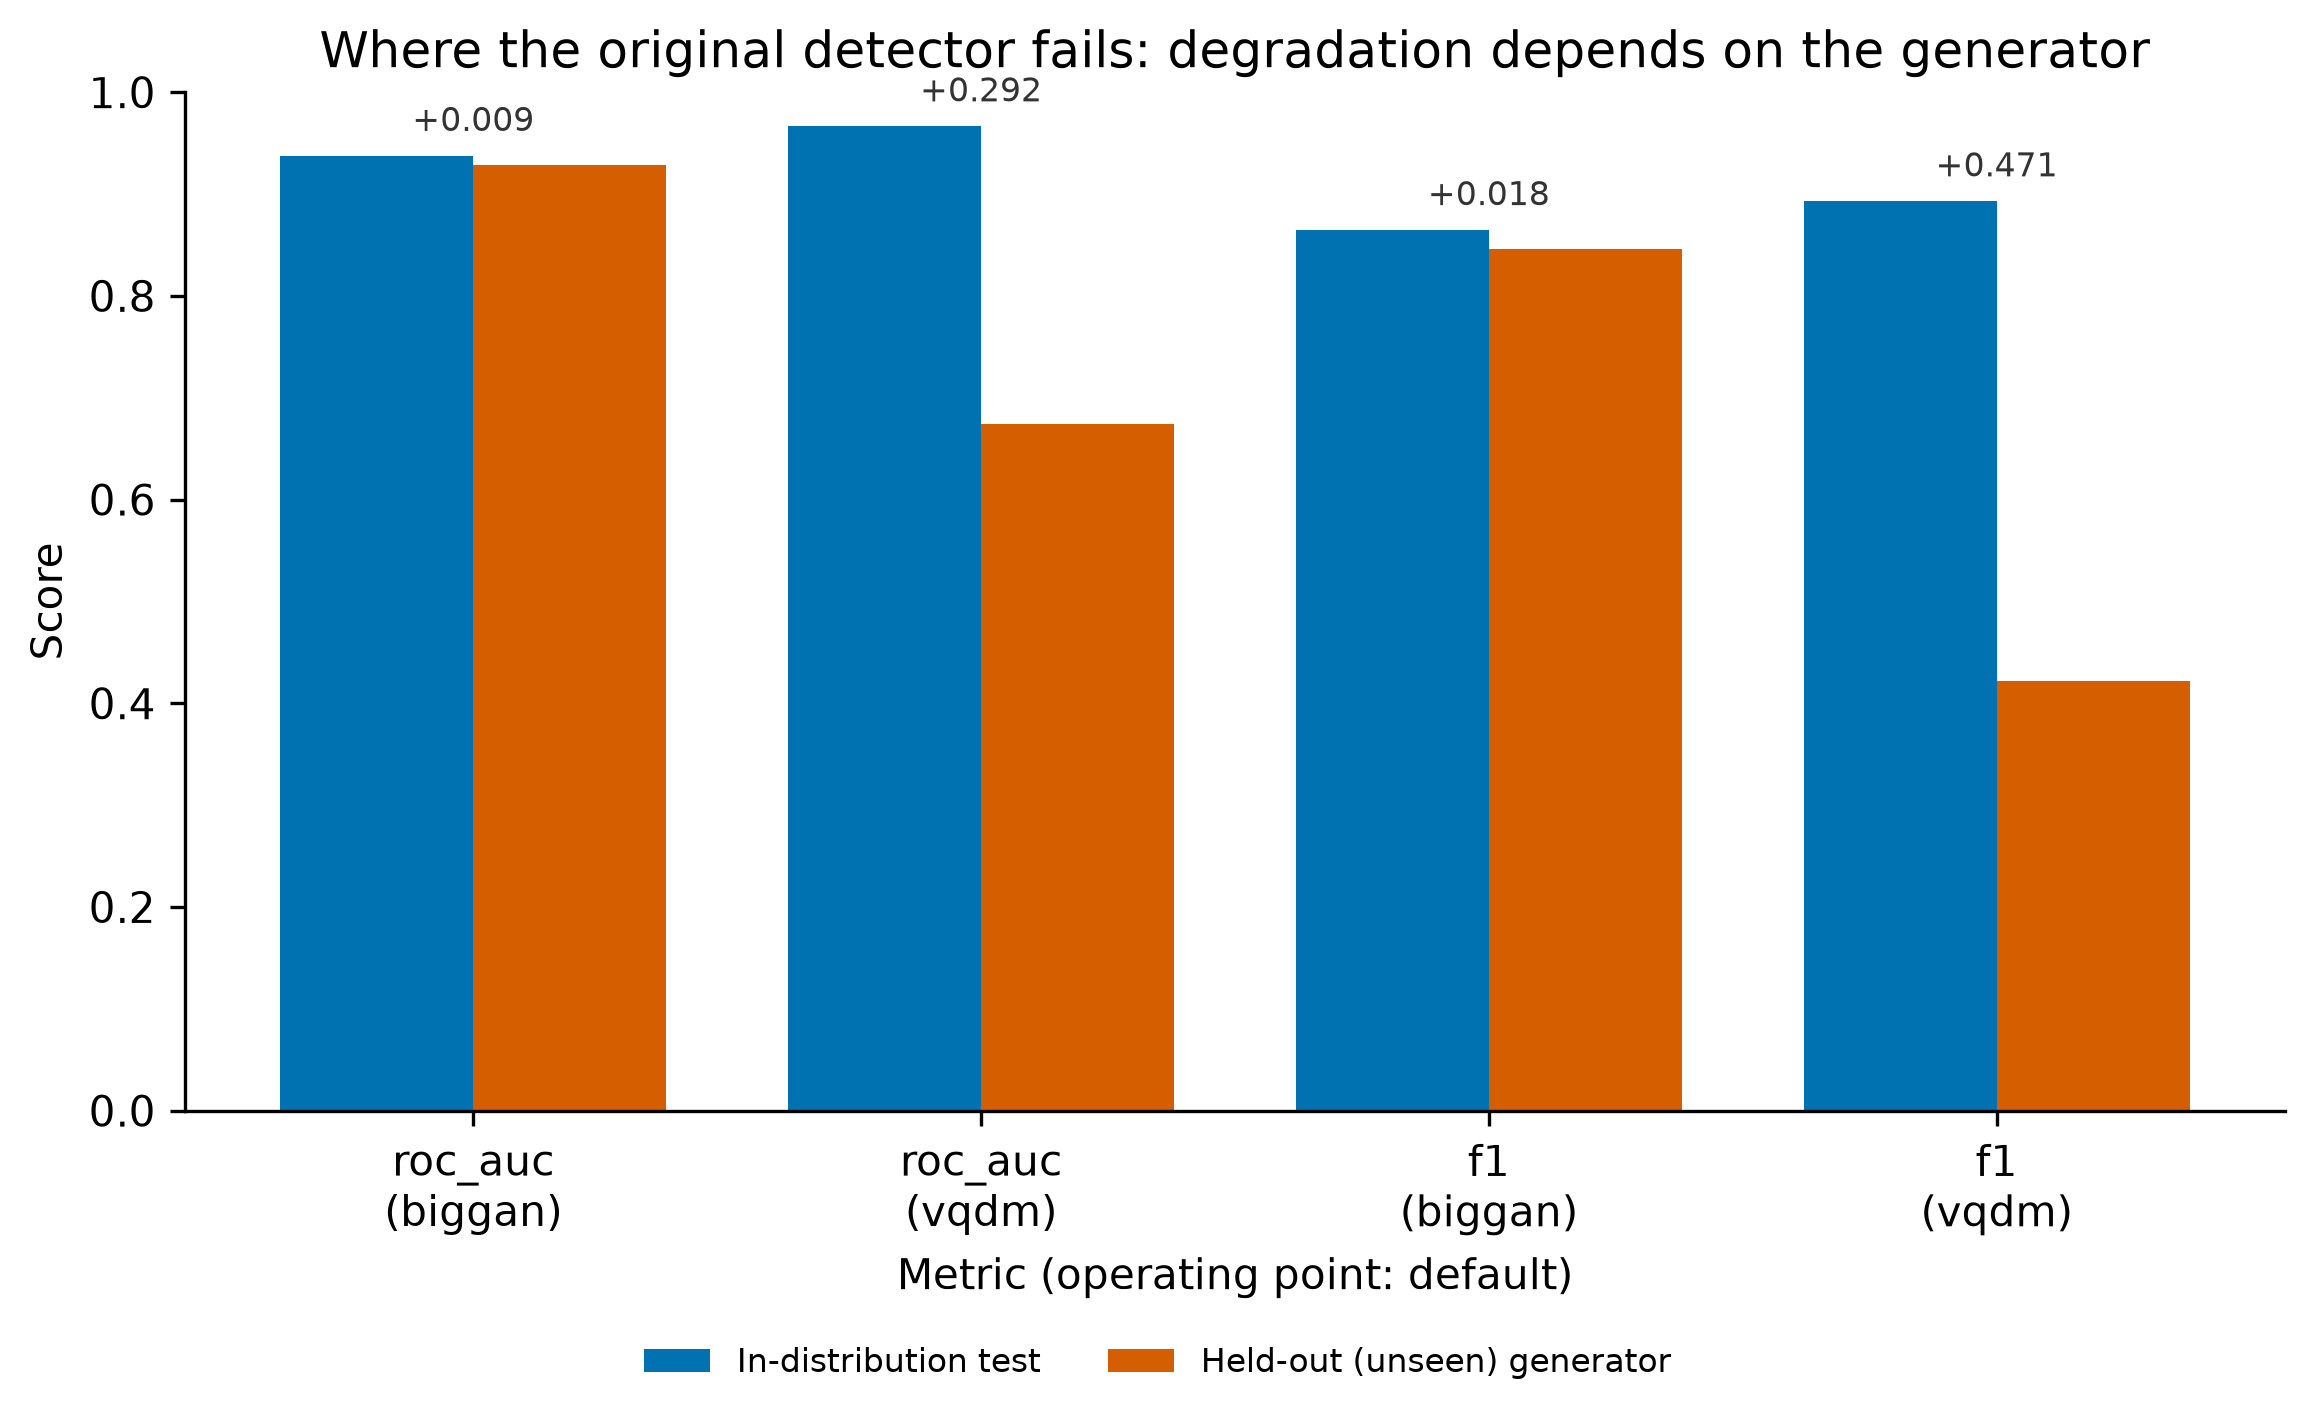

**Say:** The detector barely notices one unseen generator and collapses on another (biggan -0.009; vqdm -0.292 ROC-AUC).

**Shows:** That generator shift is not one phenomenon: robustness measured on a single held-out generator would have been badly misleading.

**Caveat:** Two generators, one seed each, at the fixed 0.5 threshold. No interval is implied and no significance is claimed.

In [2]:
show("meeting_fig1_where_it_fails")


The detector loses almost nothing on BigGAN and collapses on VQDM: ROC-AUC 0.9664 → 0.6746, and recall at the 0.5 threshold falls to **0.304** — it misses 174 of 250 VQDM fakes. That is the failure the rest of the project addresses.

---
# 2. WHAT I CHANGED

I did **not** change CLIP. The backbone stays frozen and identical — same checkpoint, same pinned revision `3d74acf9…`. What I changed is **how the 768-dimensional embedding is turned into a decision.**

| | original | modified |
|---|---|---|
| head | `Linear(768, 1)` | cosine head |
| logit | `w · x + b` | `s · cos(w, x) + b` |
| uses embedding *length*? | **yes** | **no** |
| uses embedding *direction*? | yes | yes |
| trainable parameters | **769** | **770** |

**In one sentence:** the original head can be influenced by *how long* the embedding vector is; the modified head normalises both the embedding and the weight vector to unit length, so only the **angle between them** can matter, with a single learnable temperature `s` restoring the scale the sigmoid needs.

**Why this is a fair comparison.** 770 parameters against 769. If it helps, nobody can say *"you just gave it a bigger head"* — that is the confound that makes most head-swapping results uninterpretable. Everything else is held constant: same generators, splits, seed, epochs, learning rate, threshold policy, and a byte-identical test set (`861b69f7…`).

**Original motivation.** CLIP was pretrained contrastively using cosine similarity over L2-normalised embeddings, so classifying the *unnormalised* embedding is off-manifold relative to how the features were learned. I hypothesised that embedding magnitude tracks low-level image statistics (resolution, compression, texture energy) that differ by generator without being evidence of generation.

---
# 3. WHY — testing the premise before trusting the result

That motivation is a *mechanistic claim*, and it is measurable without training anything. So I measured it: encode images with the frozen backbone and compare embedding lengths across generators.

**This is the part I would lead with if asked how the change was designed.**

generator,n,mean_norm,p10_norm,median_norm,p90_norm
adm,60,27.25,26.08,27.16,28.08
real,60,27.32,26.43,27.31,28.11
wukong,60,27.32,26.63,27.28,28.13
stable_diffusion_v1_5,60,27.40,26.44,27.33,28.37
midjourney,60,27.44,26.58,27.45,28.24
vqdm,60,27.48,26.67,27.33,28.49
biggan,60,27.65,26.85,27.70,28.31
glide,60,27.68,26.85,27.55,28.79


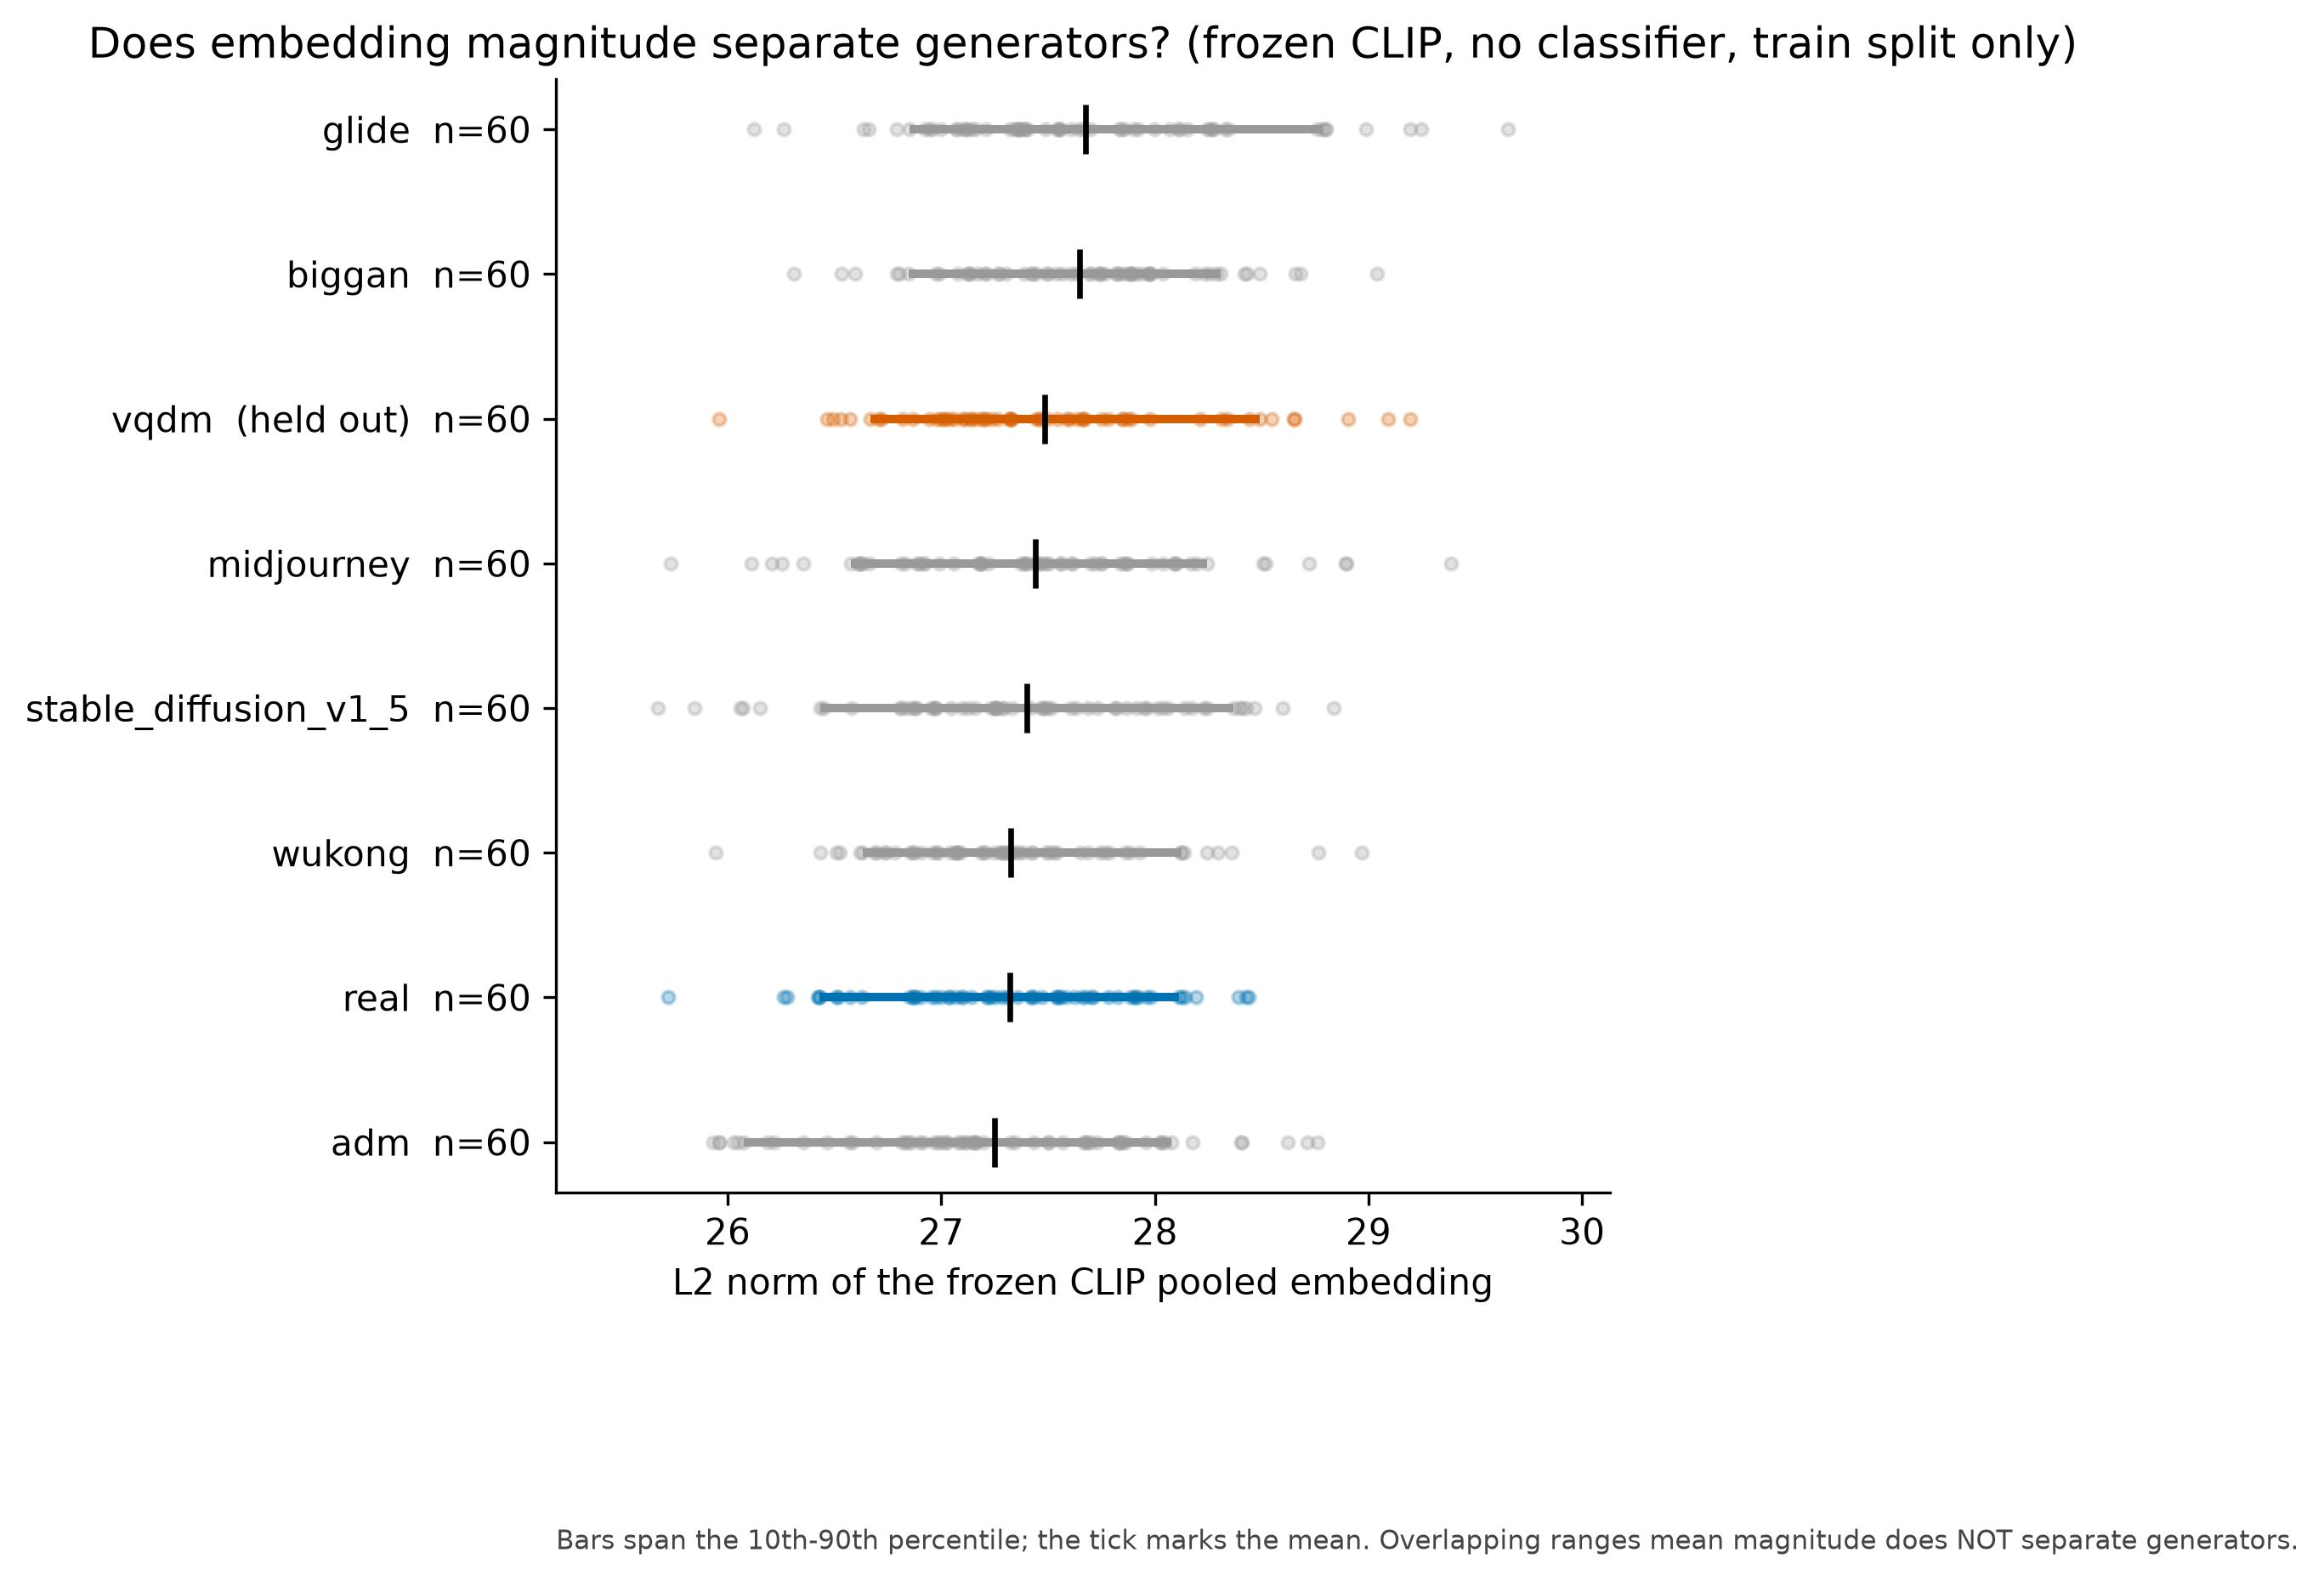

Spread of mean embedding norm across all eight groups: 0.42 (means range 27.25-27.68)


In [3]:
# Testing the PREMISE of the change, with no training involved.
# scripts/analyse_embedding_norms.py encodes 60 train-split images per generator with the
# FROZEN CLIP backbone and reports the spread of embedding lengths. The final unseen test
# partitions are never opened.
import json

norms = json.loads((ANALYSIS / "embedding_norms.json").read_text())
table = pd.DataFrame(norms["per_generator"])[
    ["generator", "n", "mean_norm", "p10_norm", "median_norm", "p90_norm"]
]
display(table.sort_values("mean_norm").reset_index(drop=True).style.format(
    precision=2).hide(axis="index"))
display(Image(filename=str(ANALYSIS / "figure_embedding_norms.png"), width=900))
spread = table["mean_norm"].max() - table["mean_norm"].min()
print(f"Spread of mean embedding norm across all eight groups: {spread:.2f} "
      f"(means range {table['mean_norm'].min():.2f}-{table['mean_norm'].max():.2f})")


### The premise, as originally stated, is NOT supported

Every generator sits at essentially the same embedding length (means ≈ 27.3–27.7, with heavily overlapping 10th–90th percentile ranges). VQDM — the generator that breaks the detector — is right in the middle of the pack.

There is a good reason, and it is worth stating because it shows the feature space was understood rather than assumed: **`pooler_output` is the output of CLIP's `post_layernorm`.** LayerNorm standardises each embedding, so its norm is nearly constant *by construction*. There was never much magnitude variation available for the linear head to exploit.

**What this changes.** The cosine head is therefore *not* mainly removing a magnitude confound. What it actually does is constrain the **weight vector** to unit norm and introduce a learnable temperature — a **regularisation and calibration** change rather than a feature-normalisation one. That is still a coherent hypothesis for this project, because the recurring finding across every experiment so far is that *ranking* (ROC-AUC) holds up while the *decision threshold* is what moves. But it is a different hypothesis from the one I started with, and the write-up will say so.

> **If asked "how did you improve it?":** *"I identified a specific failure, formed a mechanistic hypothesis, and tested the mechanism directly before spending compute on it, which showed the original hypothesis only partly holds. The controlled comparison then moved every metric in the right direction, but by less than the margin I fixed in advance as interpretable from a single seed. So I am not claiming an improvement yet."*

That is a stronger answer than a number, because it shows the experiment was designed rather than stumbled into, and that the decision rule was set before the result was seen.

---
# 4. AFTER — the controlled comparison

Same protocol, same data, same seed. Only the head differs. The quantity that matters is the **drop** — each architecture measured against **its own** matched in-distribution reference, not against the other's absolute score.

metric,linear (769 params),cosine (770 params),difference
ROC-AUC — in-distribution,0.9664,0.9659,-0.0006
ROC-AUC — unseen vqdm,0.6746,0.6921,+0.0175
ROC-AUC — DEGRADATION,0.2918,0.2738,-0.0180
PR-AUC — in-distribution,0.9682,0.9677,-0.0005
PR-AUC — unseen vqdm,0.6746,0.6872,+0.0126
PR-AUC — DEGRADATION,0.2936,0.2805,-0.0131
F1@0.5 — in-distribution,0.8928,0.9004,+0.0076
F1@0.5 — unseen vqdm,0.4222,0.4318,+0.0096
F1@0.5 — DEGRADATION,0.4706,0.4686,-0.0020
unseen recall@0.5,0.3040,0.3040,+0.0000


### Verdict against the rule fixed BEFORE the run: **INCONCLUSIVE**

Every direction favours the cosine head — degradation 0.2918 → 0.2738, unseen ROC-AUC 0.6746 → 0.6921 (+0.0175), in-distribution essentially unchanged (-0.0006) — but the gain of **+0.0175 ROC-AUC is below the 0.05 threshold** fixed in advance as the smallest difference interpretable from a single seed. **Do not claim an improvement from this run alone.**

### 2. Can the modified detector withstand the shift?

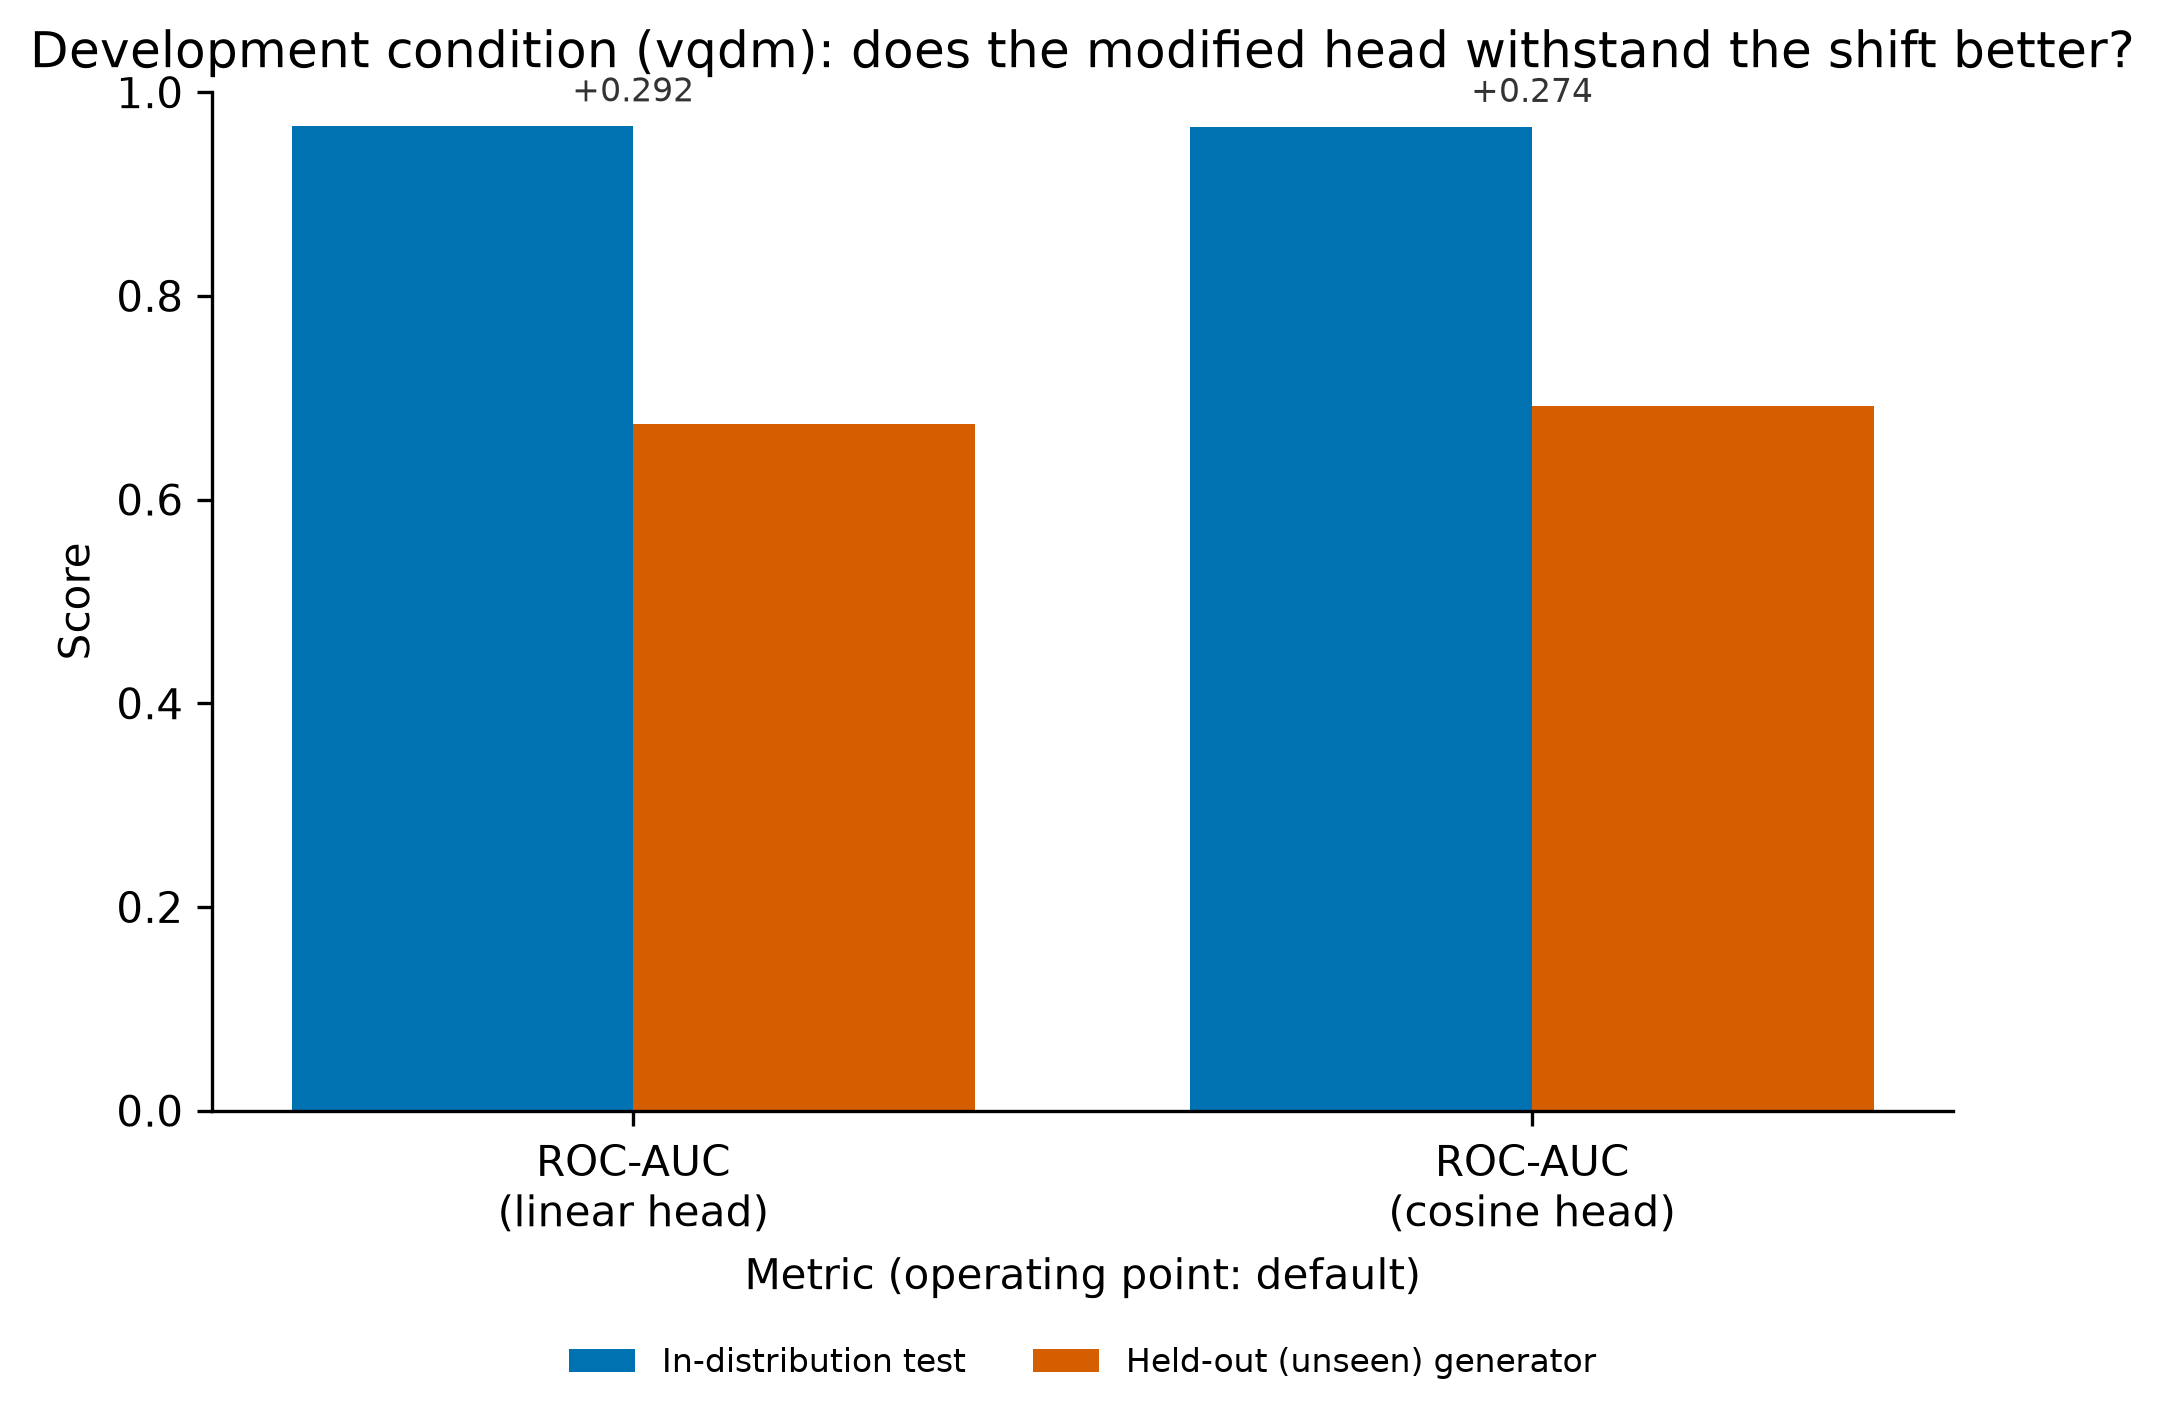

**Say:** Each bar pair is one architecture's own in-distribution reference next to its unseen score, so the comparison is between DROPS, not absolute scores.

**Shows:** Whether removing embedding magnitude from the decision reduces generator-shift degradation, at matched parameter count (769 vs 770).

**Caveat:** vqdm motivated this architecture, so it is a DEVELOPMENT condition; wukong is pre-declared as the confirmatory zero-shot test.

In [4]:
result = cosine_result()
if result is None:
    display(Markdown(
        "> ### ⏳ The modified detector has not finished training yet.\n"
        "> \n"
        "> No result is shown, and none is estimated. When "
        "`configs/tiny_unseen_vqdm_cosine.yaml` completes, re-running this notebook fills "
        "in the second bar pair below automatically.\n"
        "> \n"
        "> **Decision rule, fixed in advance** (original drop = 0.292 ROC-AUC):\n"
        "> \n"
        "> | outcome | criterion |\n"
        "> |---|---|\n"
        "> | convincing | drop ≤ 0.15, unseen ROC-AUC ≥ 0.82, in-distribution within ~0.01 |\n"
        "> | inconclusive | unseen improves by < 0.05 ROC-AUC |\n"
        "> | failure | drop ≥ 0.29, or in-distribution degrades |\n"
        "> \n"
        "> With one seed, a difference below ~0.05 ROC-AUC is **not interpretable**."
    ))
else:
    # Side-by-side, both heads, every number from the two runs' own metrics files.
    comparison = pd.DataFrame(head_comparison())
    display(comparison.style.format(
        {"linear (769 params)": "{:.4f}", "cosine (770 params)": "{:.4f}",
         "difference": "{:+.4f}"}).hide(axis="index"))

    verdict, reason = classify(result)
    display(Markdown(
        f"### Verdict against the rule fixed BEFORE the run: **{verdict}**\n\n{reason}"
    ))
show("meeting_fig2_modified_detector")


### The methodological point to make *before* this figure

VQDM is what exposed the failure, so it **motivated** the architecture. The model never sees VQDM — there is no data leakage — but *I* have. That makes VQDM a **development** condition, not a clean zero-shot test.

**Wukong has never been held out in any run of this project.** It is **pre-declared, in config comments written before the run**, as the confirmatory test of the zero-shot claim (`configs/tiny_unseen_wukong_cosine.yaml`).

Saying this before showing the figure turns the obvious objection into evidence of experimental control.

---
# 5. SUPPORTING EVIDENCE

Three further experiments, each answering a question the previous one raised.

### 3. How quickly can it recover?

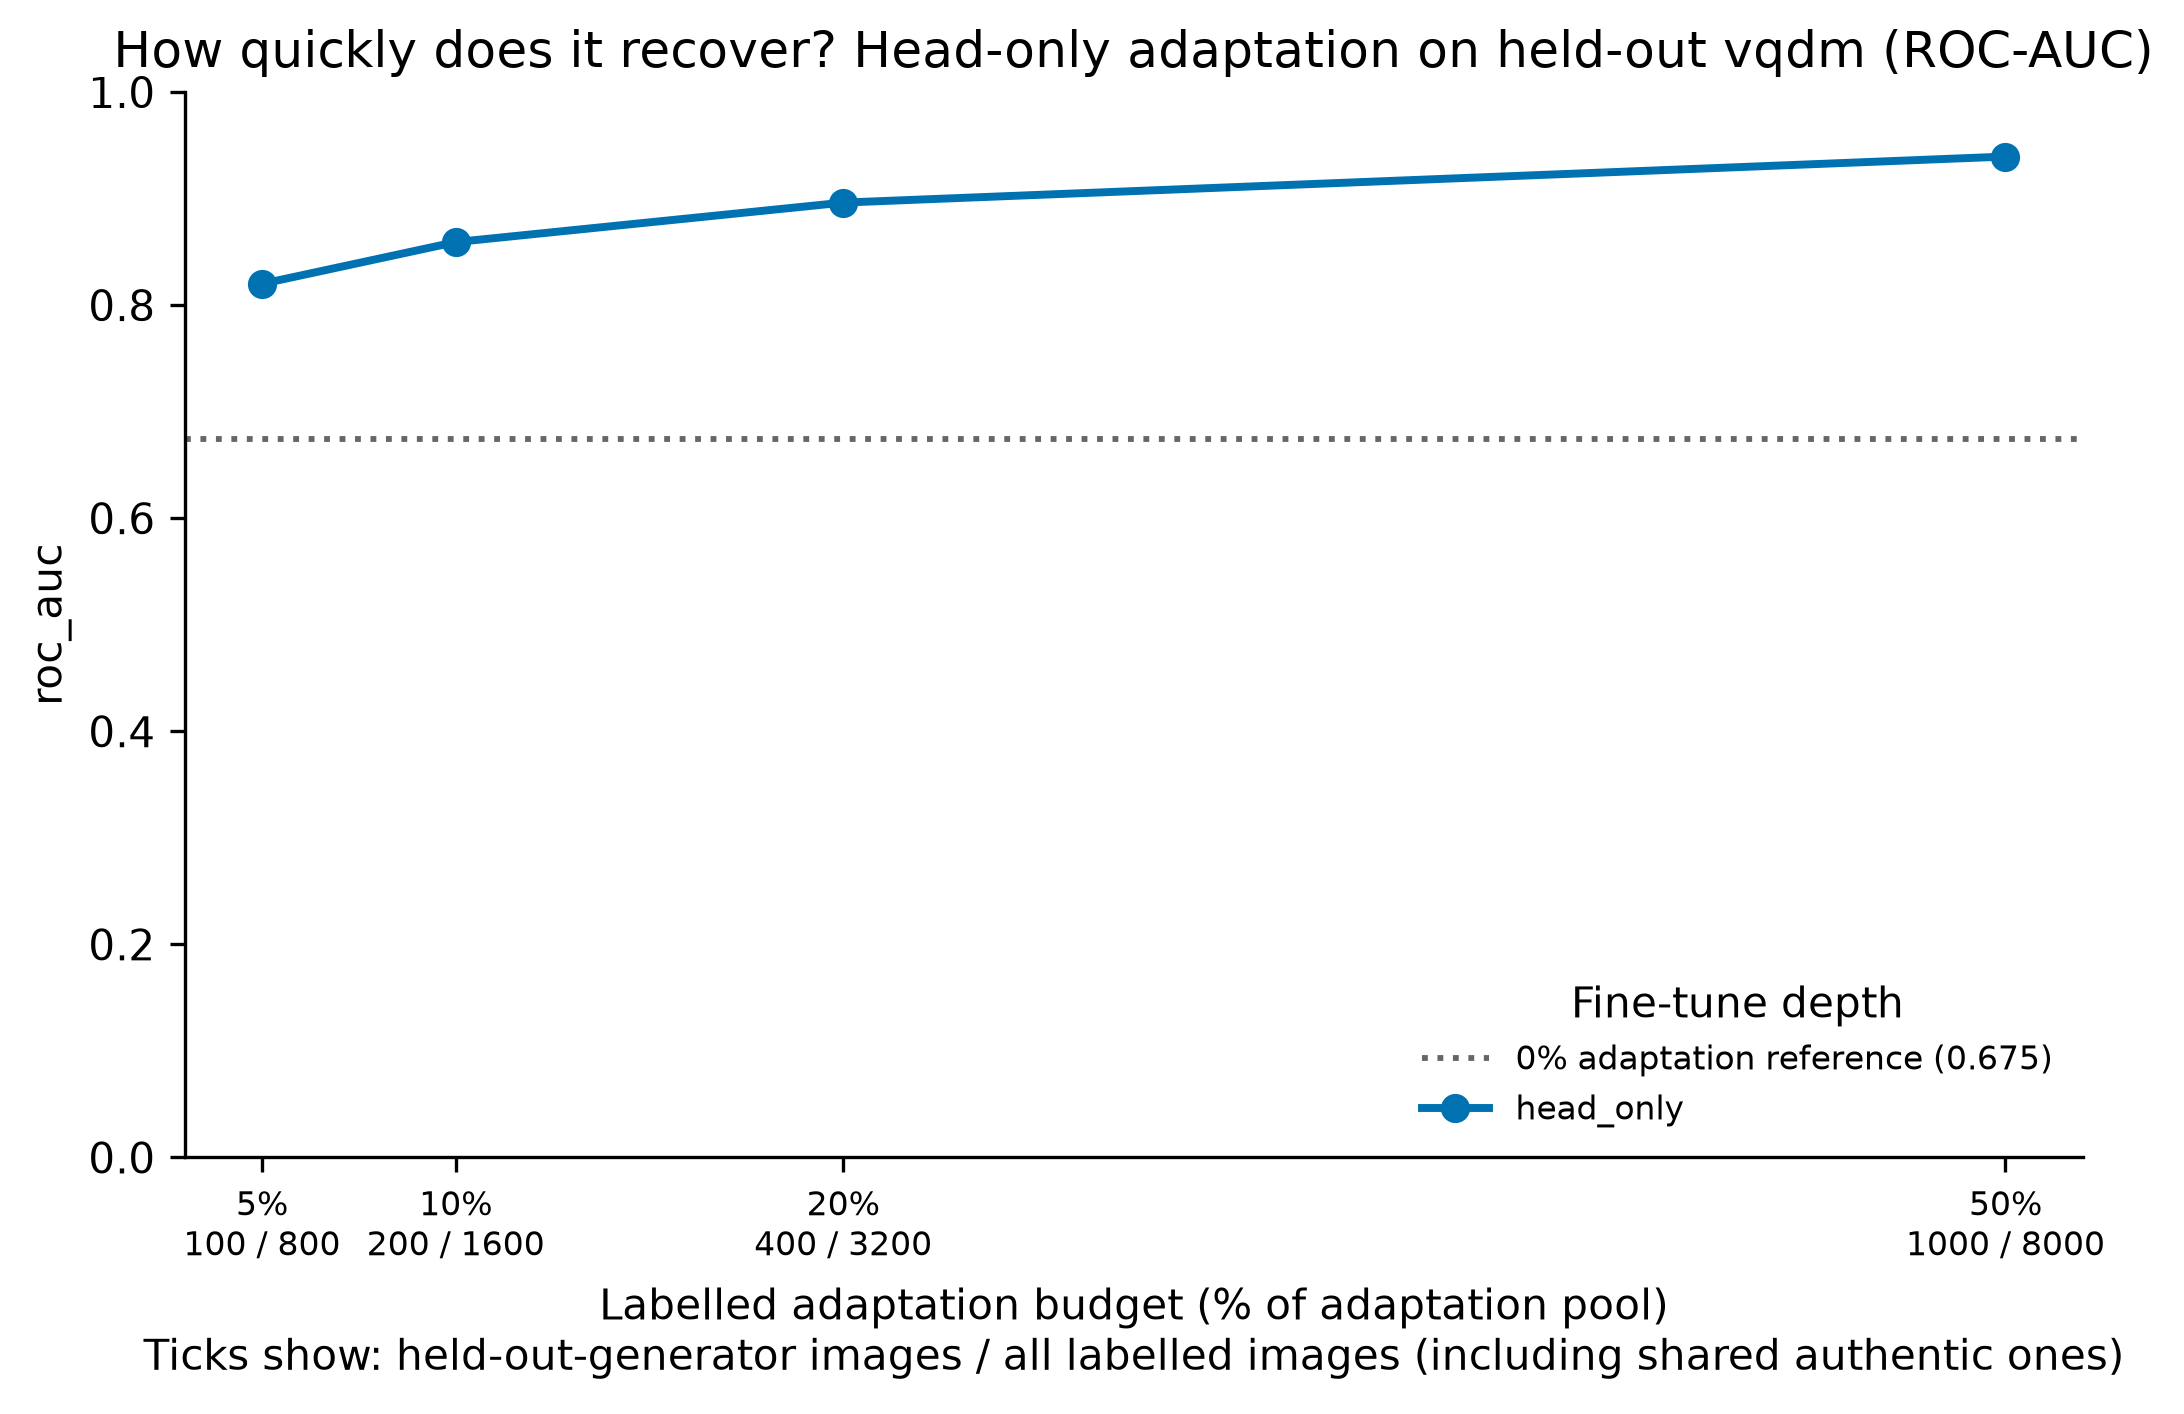

**Say:** A few hundred labelled vqdm images take ROC-AUC from 0.675 to 0.939.

**Shows:** That the failure is recoverable with limited labels, so the problem is adaptation cost rather than a permanent blind spot.

**Caveat:** This is recovery AFTER exposure to the new generator; it is a different question from zero-shot robustness. Original head only; single seed.

In [5]:
show("meeting_fig3_recovery")

### 4. How much of CLIP needs to change?

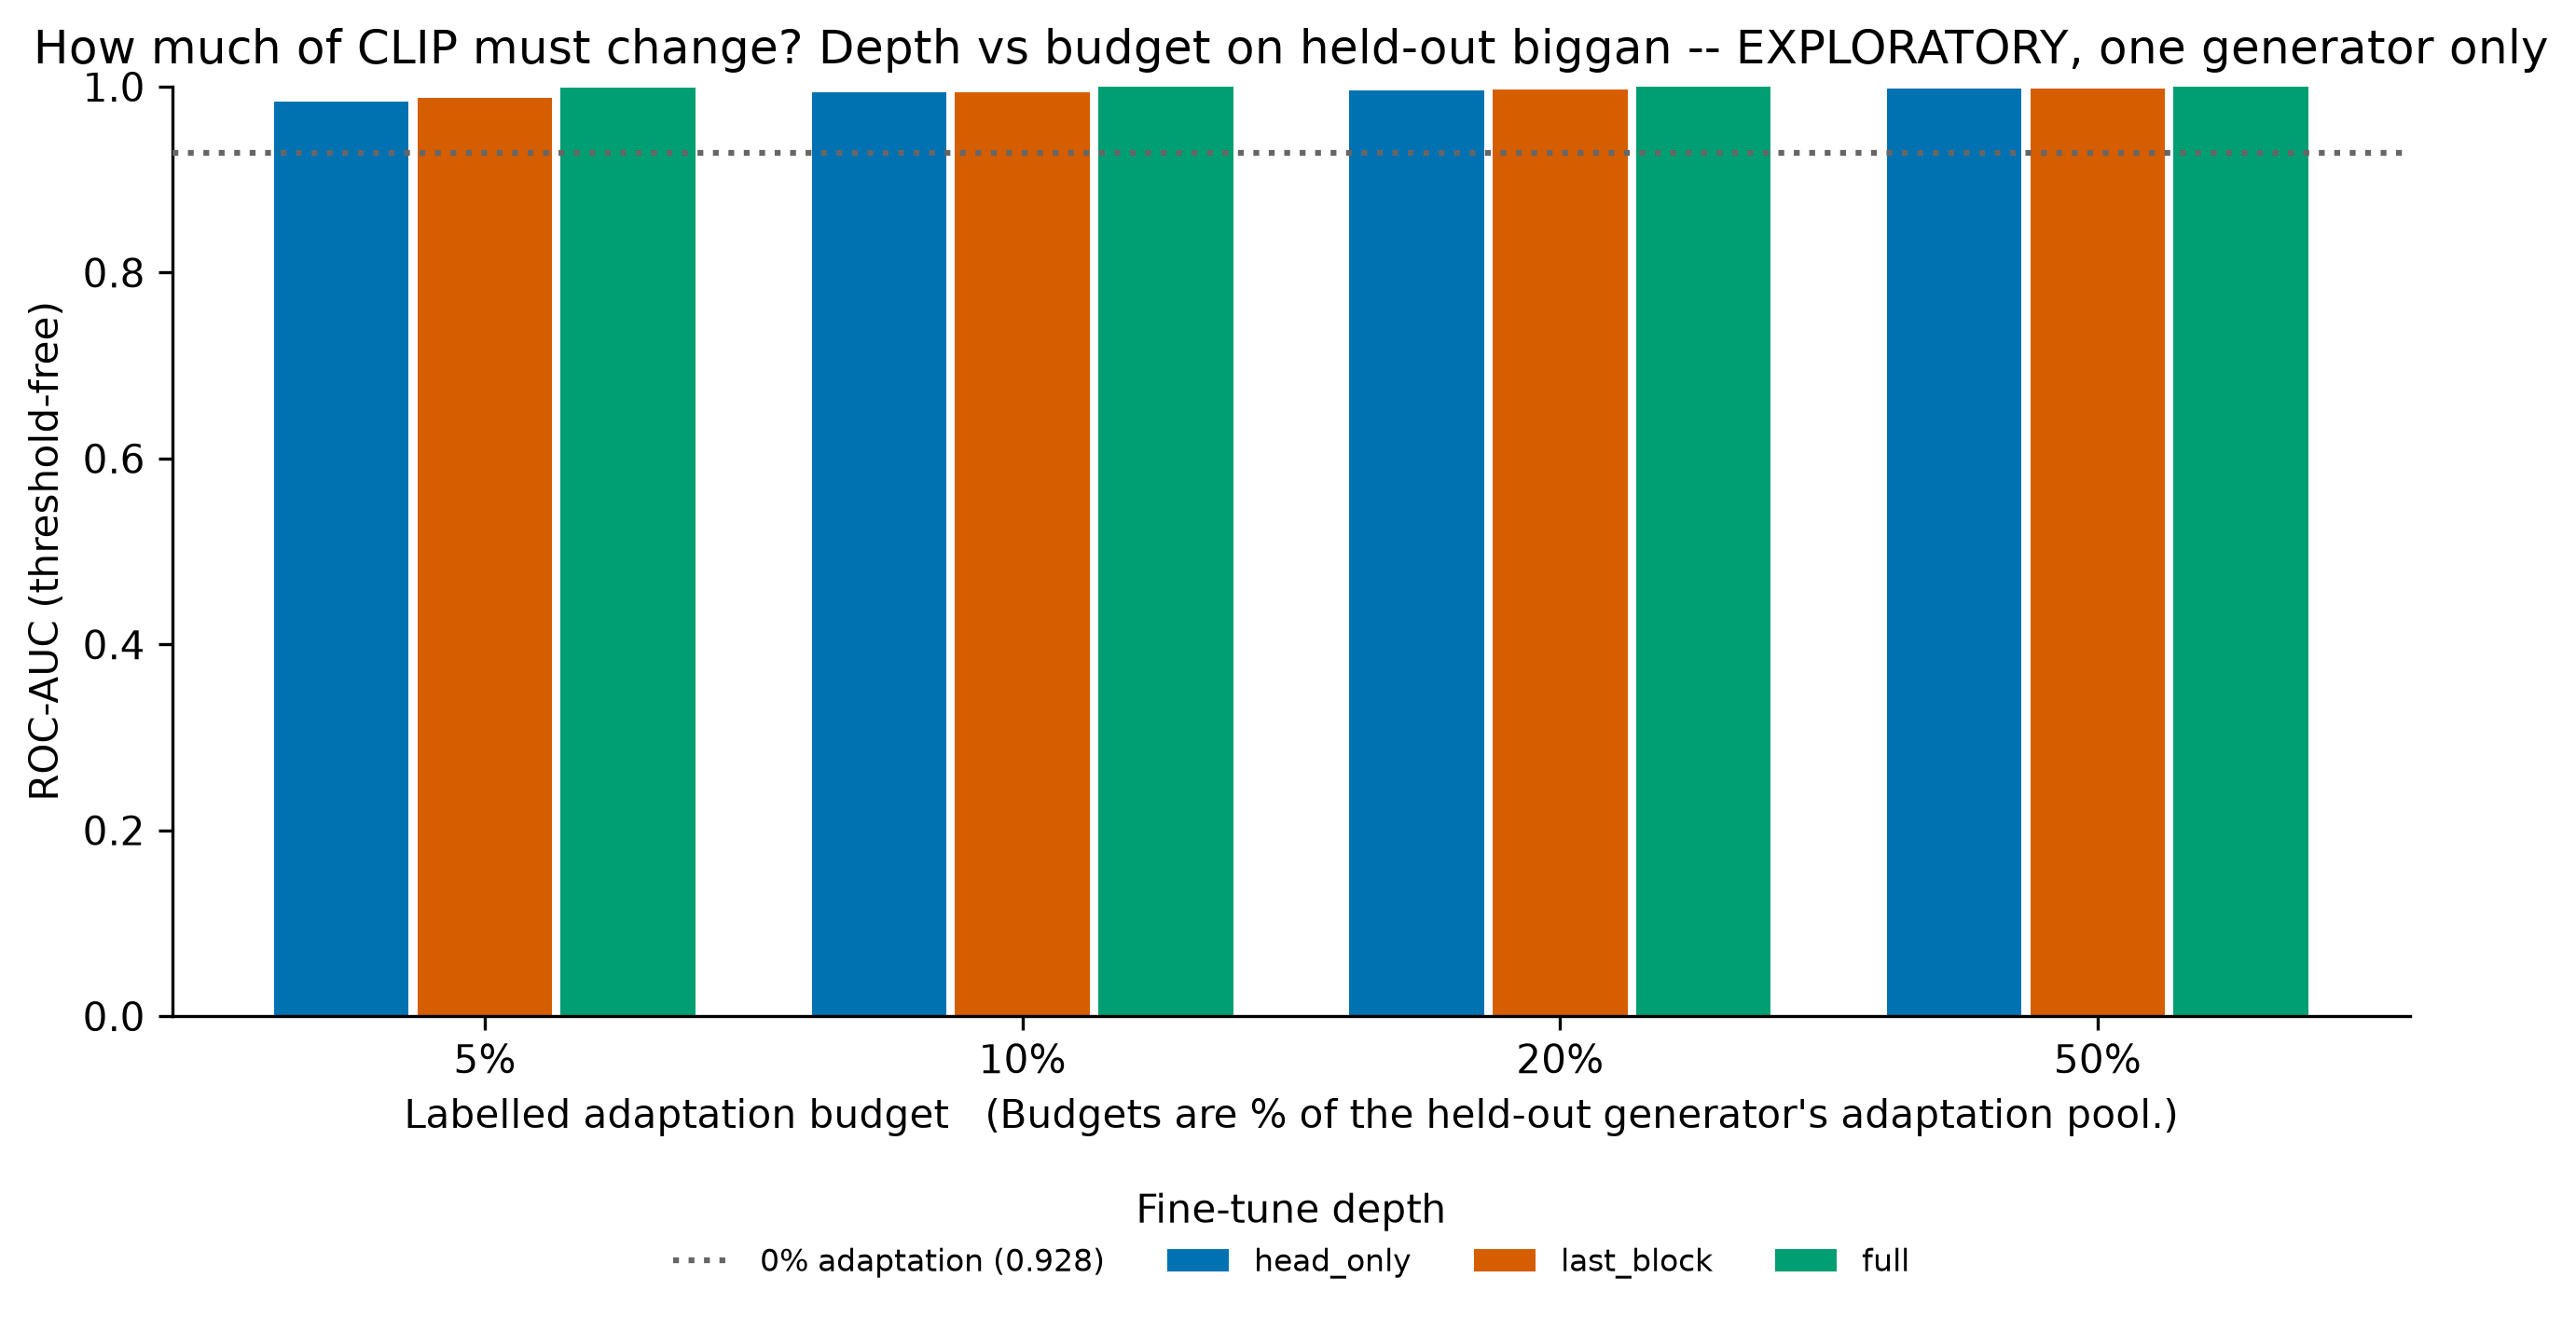

**Say:** Every depth exceeds 0.98 ROC-AUC at every budget, including the 769-parameter head.

**Shows:** That representation-level adaptation is not required for ranking on this generator; the depths separate at a fixed threshold, not in ranking.

**Caveat:** biggan-only and EXPLORATORY: biggan barely degraded in the first place, so there was little for depth to repair. Learning rate differs by depth (1e-3 head-only, 1e-5 otherwise). Single seed.

In [6]:
show("meeting_fig4_depth")

### 5. Where the project is going

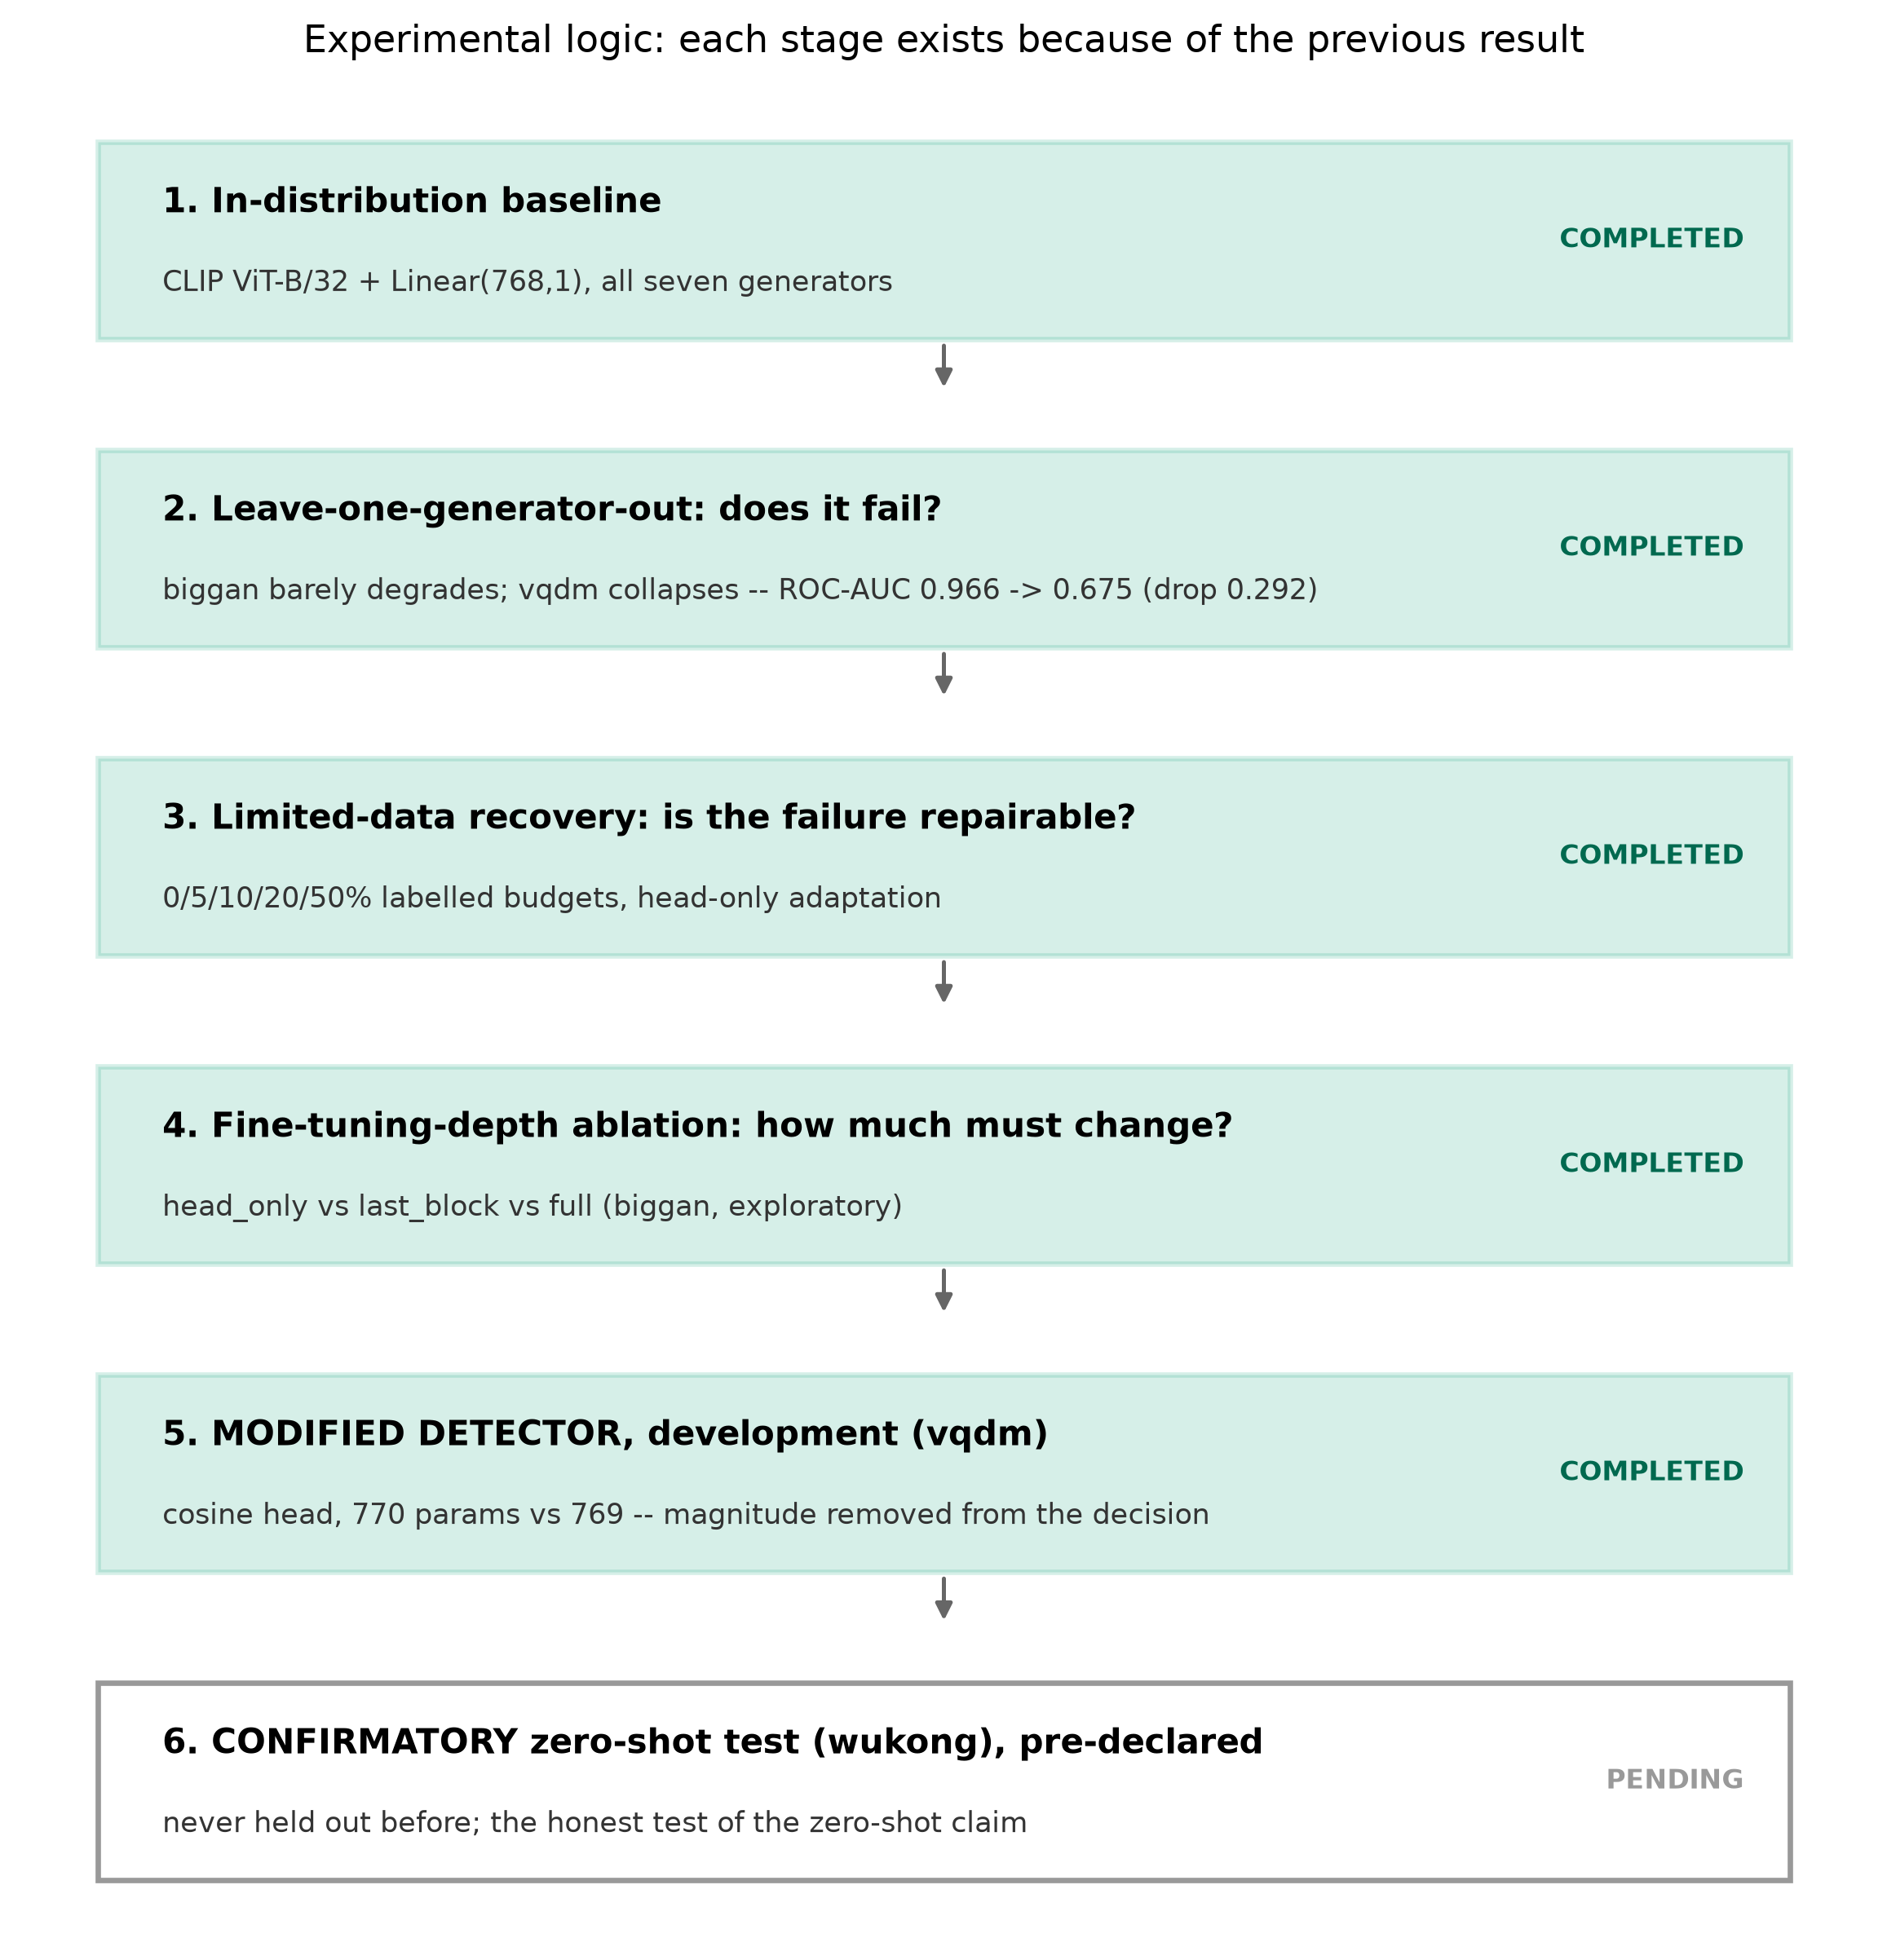

**Say:** Each experiment was chosen because of what the previous one showed, and the confirmatory test is pre-declared rather than picked afterwards.

**Shows:** That the project is a controlled sequence of model-development experiments, not a single pretrained model evaluated repeatedly.

**Caveat:** Stages marked PENDING have not been run; nothing about their outcome is implied here.

In [7]:
show("meeting_fig5_roadmap", width=780)

---
# 6. RESULTS TABLES

Every completed condition. `roc_auc_drop` is the quantity the project is about: matched in-distribution performance minus unseen-generator performance.

In [8]:
headline = pd.read_csv(PACK / "meeting_table_headline_results.csv")
display(headline.style.format(precision=4, na_rep="—").hide(axis="index"))


condition,head,in_distribution_roc_auc,roc_auc,roc_auc_drop,pr_auc,f1_at_0.5,recall_at_0.5,run_id
unseen biggan @ 0%,linear,0.9374,0.9284,0.0090,0.9243,0.8462,0.8360,unseen_generator-20260808T151948963300Z-c74c3e0db3-363b
unseen vqdm @ 0%,cosine,0.9659,0.6921,0.2738,0.6872,0.4318,0.3040,unseen_generator-20260816T230229229836Z-e41f75118f-3e37
unseen vqdm @ 0%,linear,0.9664,0.6746,0.2918,0.6746,0.4222,0.3040,unseen_generator-20260816T191041040059Z-4c30e188fc-e073
biggan @ 5% (head_only),linear,—,0.9843,—,0.9833,0.8519,0.7480,fine_tuning-20260808T171227711418Z-314210675e-90fa
biggan @ 10% (head_only),linear,—,0.9938,—,0.9935,0.8952,0.8200,fine_tuning-20260808T171227711418Z-314210675e-90fa
biggan @ 20% (head_only),linear,—,0.9960,—,0.9958,0.9302,0.8800,fine_tuning-20260808T171227711418Z-314210675e-90fa
biggan @ 50% (head_only),linear,—,0.9975,—,0.9975,0.9633,0.9440,fine_tuning-20260808T171227711418Z-314210675e-90fa
biggan @ 5% (head_only),linear,—,0.9843,—,0.9833,0.8519,0.7480,ablation-20260816T163436467712Z-fc1a22d8e3-4f83
biggan @ 10% (head_only),linear,—,0.9938,—,0.9935,0.8952,0.8200,ablation-20260816T163436467712Z-fc1a22d8e3-4f83
biggan @ 20% (head_only),linear,—,0.9960,—,0.9958,0.9302,0.8800,ablation-20260816T163436467712Z-fc1a22d8e3-4f83


### Experiment inventory

Including runs that failed or were interrupted. These contribute **nothing** to any figure or table above.

In [9]:
rows = []
for record in records:
    head = "cosine" if record.experiment_name.endswith("_cosine") else "linear"
    rows.append({
        "experiment": record.experiment_name,
        "protocol": record.experiment_type,
        "head": head,
        "held out": record.held_out_generator or "—",
        "status": "INCLUDED" if record in usable else (
            "smoke" if record.is_synthetic_smoke else record.status),
    })
display(pd.DataFrame(rows).sort_values(["protocol", "experiment"]).reset_index(drop=True))


,experiment,protocol,head,held out,status
0,tiny_ablation_biggan,ablation,linear,biggan,incomplete
1,tiny_ablation_biggan,ablation,linear,biggan,incomplete
2,tiny_ablation_biggan,ablation,linear,biggan,INCLUDED
3,tiny_genimage_all_seven_baseline,baseline,linear,—,INCLUDED
4,SMOKE_synthetic_recovery_biggan,fine_tuning,linear,biggan,smoke
5,tiny_recovery_biggan,fine_tuning,linear,biggan,INCLUDED
6,tiny_recovery_vqdm,fine_tuning,linear,vqdm,INCLUDED
7,SMOKE_synthetic_unseen_biggan,unseen_generator,linear,biggan,smoke
8,tiny_unseen_biggan,unseen_generator,linear,biggan,failed
9,tiny_unseen_biggan,unseen_generator,linear,biggan,INCLUDED


---
# 7. NEXT

1. **`tiny_unseen_vqdm_cosine`** — the modified detector on the development condition (~1.5 h). *Running now.*
2. **`tiny_unseen_wukong` + `tiny_unseen_wukong_cosine`** — the confirmatory pair (~3 h). This is what the zero-shot claim actually rests on.
3. **Repeated seeds**, so a modest difference becomes interpretable at all.
4. If the cosine head helps: a VQDM depth ablation, since VQDM is the generator where representation failure genuinely exists.
